## Spam Model

In [14]:
pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 8.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 14.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 14.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 17.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 21.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 18.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 17.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 19.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 14.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 19.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 16.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 5.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Load processed spam data
spam_df = pd.read_csv('../data/processed/processed_spam.csv')
print(f"Shape: {spam_df.shape}")
print(f"Distribution: {spam_df['spam'].value_counts().to_dict()}")

Shape: (7865, 2)
Distribution: {0: 4238, 1: 3627}


In [7]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(classification_report(y_true, y_pred, target_names=['Not Spam', 'Spam']))
    
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC: {auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Not Spam', 'Spam'],
                yticklabels=['Not Spam', 'Spam'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

In [9]:
subset, _ = train_test_split(spam_df, test_size=0.8, random_state=42, stratify=spam_df['spam'])

X_train, X_val, y_train, y_val = train_test_split(
    subset['text'], subset['spam'],
    test_size=0.2, random_state=42, stratify=subset['spam']
)

print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 1258 | Val: 315



Model: Logistic Regression + TF-IDF
              precision    recall  f1-score   support

    Not Spam       0.87      0.88      0.88       170
        Spam       0.86      0.85      0.85       145

    accuracy                           0.87       315
   macro avg       0.87      0.87      0.87       315
weighted avg       0.87      0.87      0.87       315

ROC-AUC: 0.9315


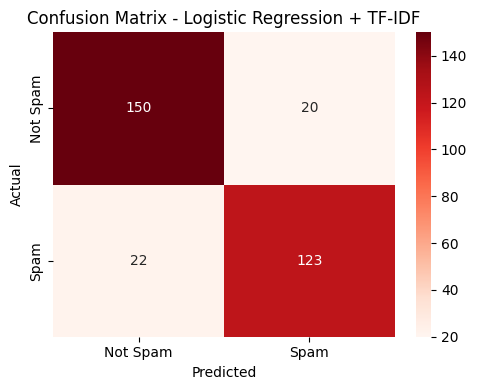

In [10]:
# Build pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred = lr_pipeline.predict(X_val)
y_prob = lr_pipeline.predict_proba(X_val)[:, 1]

# Evaluate
evaluate_model('Logistic Regression + TF-IDF', y_val, y_pred, y_prob)


Model: XGBoost + TF-IDF
              precision    recall  f1-score   support

    Not Spam       0.85      0.92      0.88       170
        Spam       0.89      0.81      0.85       145

    accuracy                           0.87       315
   macro avg       0.87      0.86      0.86       315
weighted avg       0.87      0.87      0.87       315

ROC-AUC: 0.9117


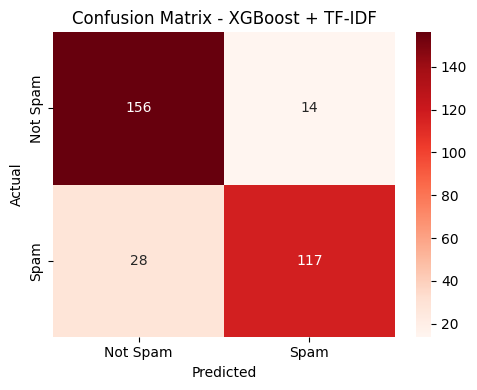

In [13]:
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])

xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_val)
y_prob = xgb_pipeline.predict_proba(X_val)[:, 1]

evaluate_model('XGBoost + TF-IDF', y_val, y_pred, y_prob)

/mnt/c/Users/DM77/youtube-comment-moderation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2240.03it/s]



Model: DistilBERT
              precision    recall  f1-score   support

    Not Spam       0.55      0.51      0.53       170
        Spam       0.47      0.51      0.49       145

    accuracy                           0.51       315
   macro avg       0.51      0.51      0.51       315
weighted avg       0.51      0.51      0.51       315



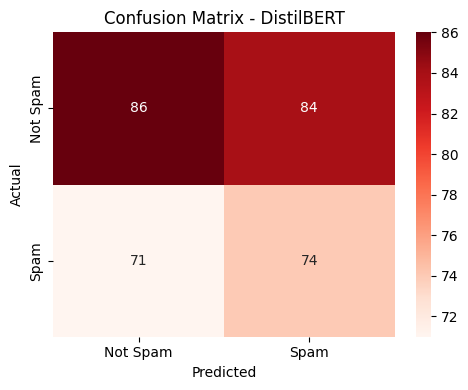

In [15]:
from transformers import pipeline

distilbert = pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=0  # GPU
)

def predict_distilbert(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        preds = distilbert(batch, truncation=True, max_length=512)
        results.extend([1 if p['label'] == 'POSITIVE' else 0 for p in preds])
    return results

y_pred = predict_distilbert(X_val)
evaluate_model('DistilBERT', y_val, y_pred)

For this first spam layer, Logistic Refression easily wins. Matches XGBoost on all metrics and better on ROC-AUD. DistilBERT performed horribly, essentially a coin toss with alot of overhead in comparison.